In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
import time

# 1. Chargement (Remplacer par le vrai fichier)
df = pd.read_csv('data_ready_to_use.csv')

# 2. Préparation de la Cible (Discrétisation)
target_col = "LIT_002_FILTER_WATER_STG_TNK"

# Fonction pour créer les classes métier
def discretiser_niveau(valeur):
    if valeur < 40:
        return 0  # Classe "Bas" (< 40%)
    elif 40 <= valeur <= 60:
        return 1  # Classe "Moyen" (40% - 60%)
    else:
        return 2  # Classe "Haut" (> 60%)

# On applique la transformation sur la colonne cible
# Note : Assurez-vous que les données sont bien numériques (float/int)
y_classes = df[target_col].apply(discretiser_niveau)

# 3. Sélection des Features (X)
# On récupère l'index pour couper juste avant la cible
try:
    target_index = df.columns.get_loc(target_col)
except KeyError:
    raise ValueError(f"Colonne '{target_col}' introuvable.")

# On prend tout ce qui est AVANT la colonne target
X = df.iloc[:, :target_index]

print(f"Dimensions X : {X.shape}")
print(f"Distribution des classes :\n{y_classes.value_counts()}")

# 4. Split Train / Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_classes, test_size=0.2, random_state=42, stratify=y_classes
)
# Note : 'stratify=y_classes' est important ici pour garder la même proportion
# de classes (Bas/Moyen/Haut) dans le train et le test set.

# 5. Standardisation (Toujours obligatoire pour KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Configuration du Modèle (Classification)
# n_jobs=-1 pour utiliser tous les coeurs
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

# 7. Entraînement
print("Début de l'entraînement...")
start_time = time.time()

knn.fit(X_train_scaled, y_train)

train_time = time.time() - start_time
print(f"Entraînement terminé en {train_time:.2f} secondes.")


# 8. Évaluation CORRIGÉE
print("Calcul des prédictions sur le Test Set...")
y_pred = knn.predict(X_test_scaled)

print(f"Précision globale (Accuracy) : {accuracy_score(y_test, y_pred):.4f}")

# Vérification pour comprendre quelles classes sont présentes
classes_presentes = sorted(y_test.unique())
print(f"Classes réellement présentes dans le test : {classes_presentes}") 
# Si vous voyez [0, 2], cela confirme qu'il n'y a pas de données entre 40% et 60%.

print("\nRapport détaillé par classe :")
target_names = ['Bas (<40%)', 'Moyen (40-60%)', 'Haut (>60%)']

# Le paramètre 'labels=[0, 1, 2]' force sklearn à afficher les 3 classes
# même si l'une d'elles a un score de 0.
print(classification_report(y_test, y_pred, labels=[0, 1, 2], target_names=target_names, zero_division=0))

Dimensions X : (449002, 23)
Distribution des classes :
LIT_002_FILTER_WATER_STG_TNK
2    438915
1      7395
0      2692
Name: count, dtype: int64
Début de l'entraînement...
Entraînement terminé en 0.17 secondes.
Calcul des prédictions sur le Test Set...
Précision globale (Accuracy) : 0.9956
Classes réellement présentes dans le test : [0, 1, 2]

Rapport détaillé par classe :
                precision    recall  f1-score   support

    Bas (<40%)       0.99      0.98      0.98       538
Moyen (40-60%)       0.89      0.85      0.87      1479
   Haut (>60%)       1.00      1.00      1.00     87784

      accuracy                           1.00     89801
     macro avg       0.96      0.94      0.95     89801
  weighted avg       1.00      1.00      1.00     89801



C:\Users\yass3\AppData\Local\Temp\ipykernel_12904\1889435141.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_visuel, ax=axes[0], palette="viridis", order=ordre_affichage)
C:\Users\yass3\AppData\Local\Temp\ipykernel_12904\1889435141.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_visuel, ax=axes[1], palette="viridis", order=ordre_affichage)


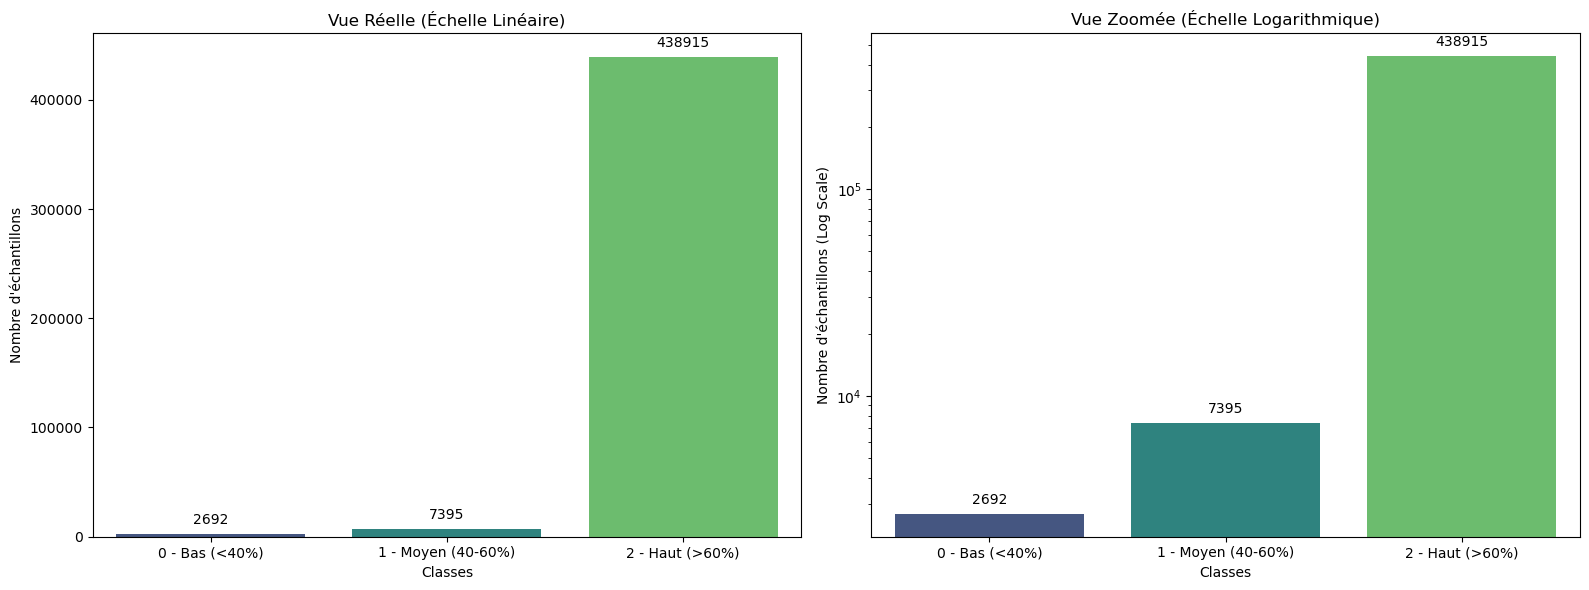

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# On définit les noms pour l'affichage
noms_classes = {0: '0 - Bas (<40%)', 1: '1 - Moyen (40-60%)', 2: '2 - Haut (>60%)'}
y_visuel = y_classes.map(noms_classes)

# --- CORRECTION ICI : On définit l'ordre complet des 3 classes ---
ordre_affichage = ['0 - Bas (<40%)', '1 - Moyen (40-60%)', '2 - Haut (>60%)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAPHIQUE 1 : Échelle Normale ---
# On utilise la variable 'ordre_affichage' qui contient les 3 classes
sns.countplot(x=y_visuel, ax=axes[0], palette="viridis", order=ordre_affichage)
axes[0].set_title("Vue Réelle (Échelle Linéaire)")
axes[0].set_ylabel("Nombre d'échantillons")
axes[0].set_xlabel("Classes")

# Annotations (Chiffres au dessus)
for p in axes[0].patches:
    height = int(p.get_height())
    # Si la hauteur est > 0 ou si on veut afficher le 0
    axes[0].annotate(f'{height}', 
                     (p.get_x() + p.get_width() / 2., height), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 10), 
                     textcoords = 'offset points')

# --- GRAPHIQUE 2 : Échelle Logarithmique ---
sns.countplot(x=y_visuel, ax=axes[1], palette="viridis", order=ordre_affichage)
axes[1].set_title("Vue Zoomée (Échelle Logarithmique)")
axes[1].set_ylabel("Nombre d'échantillons (Log Scale)")
axes[1].set_xlabel("Classes")
axes[1].set_yscale("log") 

for p in axes[1].patches:
    height = int(p.get_height())
    # Petite sécurité pour éviter erreur log(0) si la barre est vide
    if height > 0:
        axes[1].annotate(f'{height}', 
                         (p.get_x() + p.get_width() / 2., height), 
                         ha = 'center', va = 'center', 
                         xytext = (0, 10), 
                         textcoords = 'offset points')

plt.tight_layout()
plt.show()

Visualisation sur 24 colonnes et 449002 lignes.


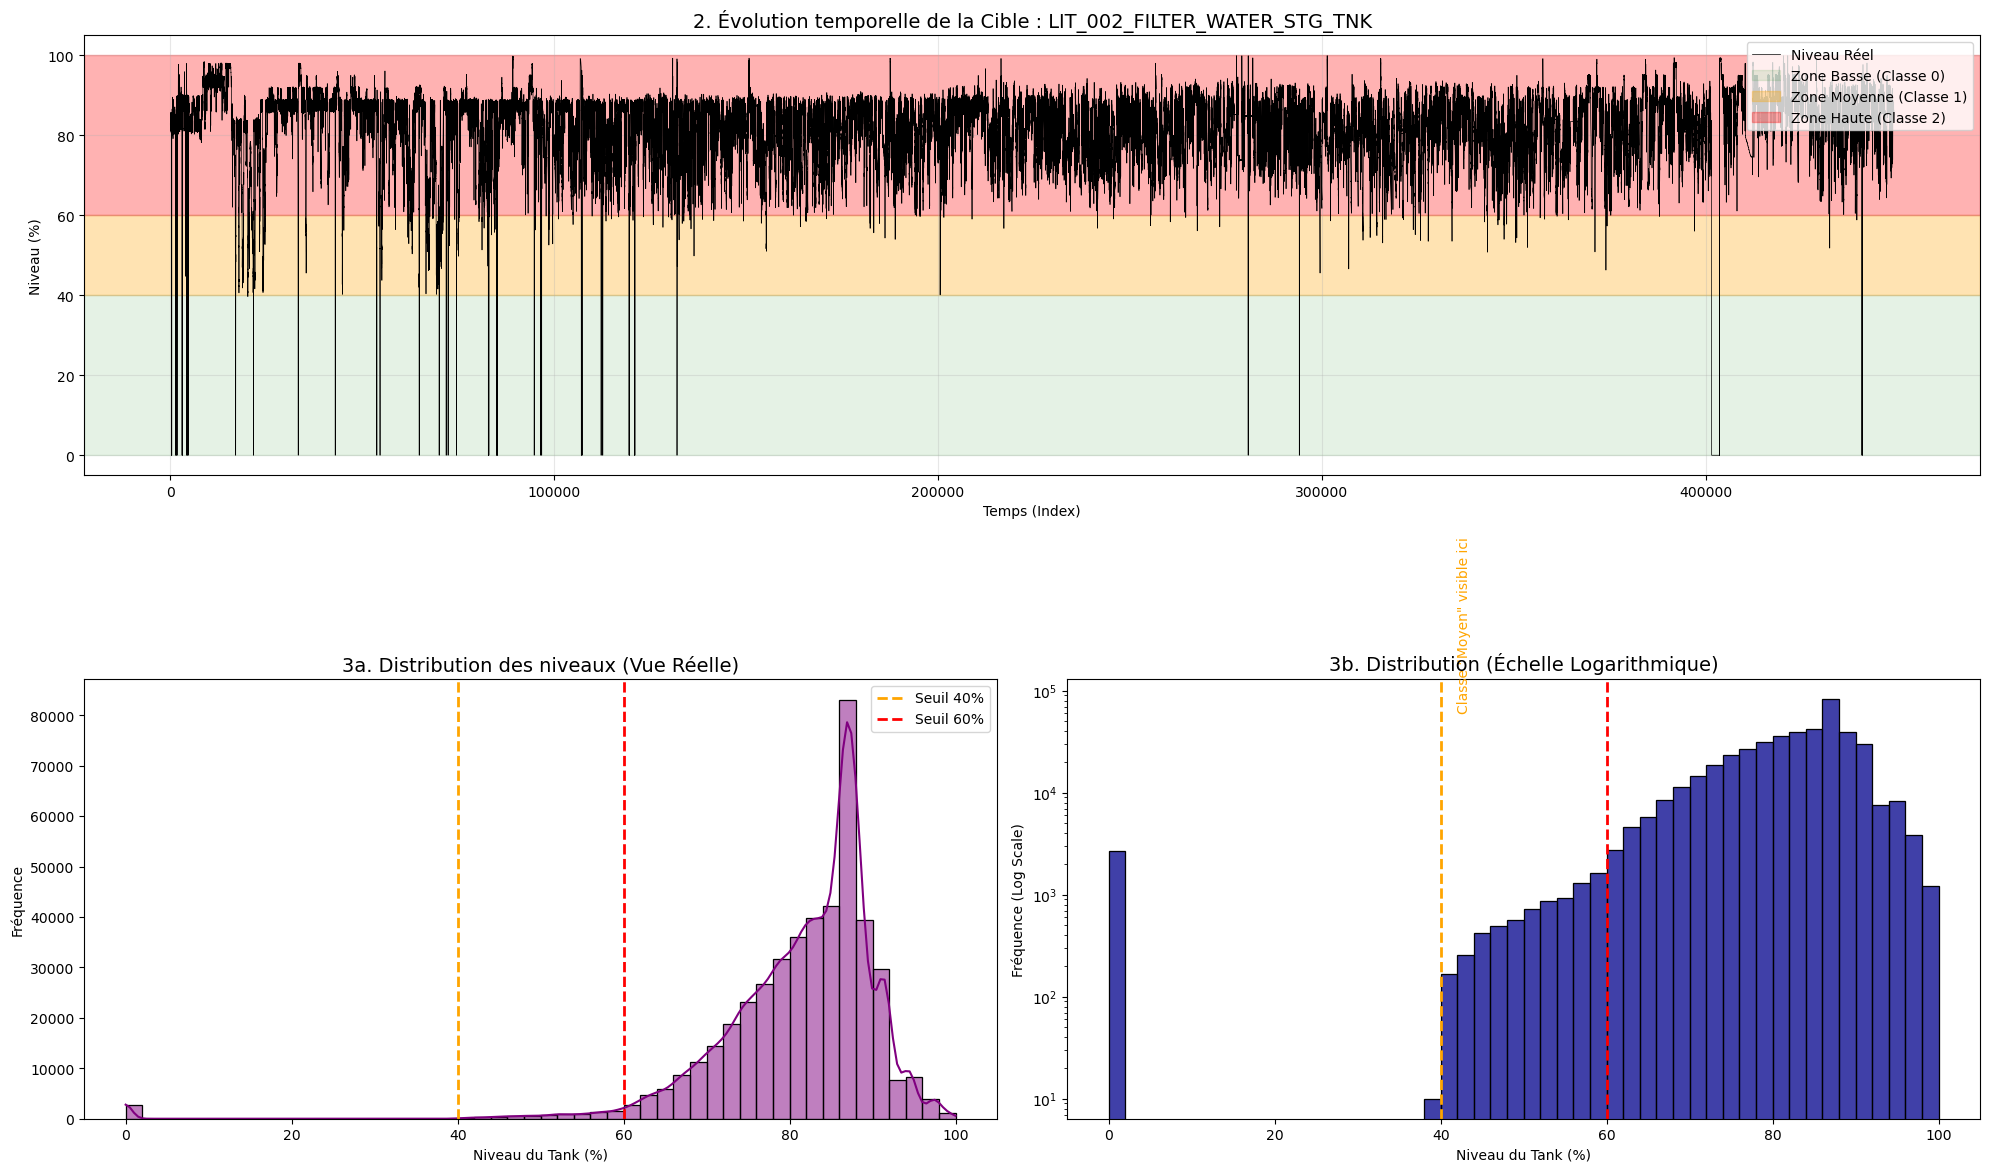

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Chargement et Sélection
df = pd.read_csv('data_ready_to_use.csv')
target_col = "LIT_002_FILTER_WATER_STG_TNK"

# On récupère les 25 colonnes + la target
try:
    target_index = df.columns.get_loc(target_col)
    df_visu = df.iloc[:, :target_index+1].copy() 
except KeyError:
    print(f"Erreur: Colonne '{target_col}' non trouvée.")
    df_visu = df.iloc[:, :26].copy()

print(f"Visualisation sur {df_visu.shape[1]} colonnes et {df_visu.shape[0]} lignes.")

# Configuration de la figure (3 lignes, 2 colonnes)
fig = plt.figure(figsize=(20, 18))
grid = plt.GridSpec(3, 2, figure=fig)



# --- GRAPHIQUE 2 : Évolution Temporelle (Timeline) ---
# Occupe toute la largeur du milieu
ax2 = fig.add_subplot(grid[1, :])
ax2.plot(df_visu[target_col], color='black', linewidth=0.5, label='Niveau Réel')

# Zones de couleur pour les classes
ax2.axhspan(0, 40, color='green', alpha=0.1, label='Zone Basse (Classe 0)')
ax2.axhspan(40, 60, color='orange', alpha=0.3, label='Zone Moyenne (Classe 1)')
ax2.axhspan(60, 100, color='red', alpha=0.3, label='Zone Haute (Classe 2)')

ax2.set_title(f"2. Évolution temporelle de la Cible : {target_col}", fontsize=14)
ax2.set_ylabel("Niveau (%)")
ax2.set_xlabel("Temps (Index)")
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)


# --- GRAPHIQUE 3 : DISTRIBUTION DU LIT (Histogramme) ---
# C'est ici que j'ai modifié pour répondre à votre demande

# Partie Gauche : Vue Classique (Linéaire)
ax3 = fig.add_subplot(grid[2, 0])
sns.histplot(df_visu[target_col], bins=50, kde=True, color='purple', ax=ax3)
ax3.set_title("3a. Distribution des niveaux (Vue Réelle)", fontsize=14)
ax3.set_xlabel("Niveau du Tank (%)")
ax3.set_ylabel("Fréquence")
# On ajoute les lignes verticales des seuils
ax3.axvline(40, color='orange', linestyle='--', linewidth=2, label='Seuil 40%')
ax3.axvline(60, color='red', linestyle='--', linewidth=2, label='Seuil 60%')
ax3.legend()

# Partie Droite : Vue Logarithmique (Pour voir les détails invisibles)
ax4 = fig.add_subplot(grid[2, 1])
sns.histplot(df_visu[target_col], bins=50, kde=False, color='darkblue', ax=ax4)
ax4.set_yscale('log') # L'astuce pour voir les petites valeurs
ax4.set_title("3b. Distribution (Échelle Logarithmique)", fontsize=14)
ax4.set_xlabel("Niveau du Tank (%)")
ax4.set_ylabel("Fréquence (Log Scale)")
# On ajoute les lignes verticales des seuils
ax4.axvline(40, color='orange', linestyle='--', linewidth=2)
ax4.axvline(60, color='red', linestyle='--', linewidth=2)
ax4.text(42, ax4.get_ylim()[1]*0.5, 'Classe "Moyen" visible ici', color='orange', rotation=90)

plt.tight_layout()
plt.show()